# 📧 EXP 2 Spam Email Detection — Structured ML Pipeline

**Pipeline Order:**
1. Imports
2. Load Data
3. EDA (Exploratory Data Analysis)
4. Preprocessing & Feature Engineering
5. Train-Test Split
6. Vectorization / Encoding
7. Model Training & Evaluation

---
## 1. 📦 Imports

In [22]:
import re 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from email import message_from_string
from scipy.sparse import hstack, csr_matrix
import mlflow

import sys
sys.path.append("/Users/kaushikchariya/Deep-Shield-Mail")

import mlflow.sklearn

# Sklearn — Preprocessing & Splitting
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Sklearn — Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)



---
## 2. 📂 Load Data

In [23]:
df = pd.read_csv('../data/spam_assassin.csv')
print("Shape:", df.shape)
df.head()

Shape: (5796, 2)


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


---
## 3. 🔍 EDA (Exploratory Data Analysis)

In [24]:
# Basic info
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (5796, 2)

Dtypes:
 text      object
target     int64
dtype: object

Null values:
 text      0
target    0
dtype: int64

Duplicates: 467


Target value counts:
 target
0    3900
1    1896
Name: count, dtype: int64


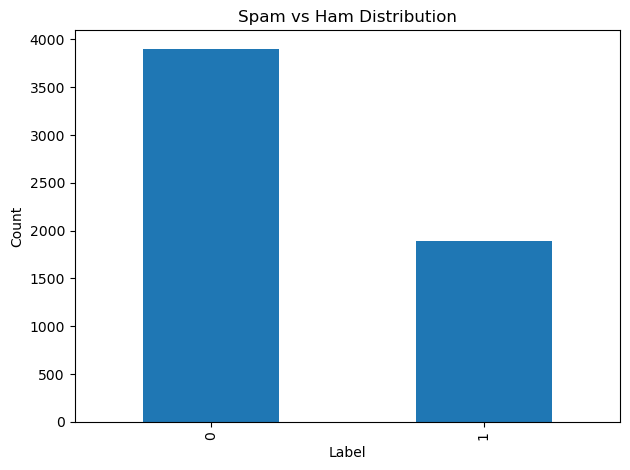

In [25]:
# Target distribution
print("Target value counts:\n", df['target'].value_counts())
df['target'].value_counts().plot(kind='bar', title='Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [26]:
# Sample raw email text
print(df['text'][5])

From tobaccodemon@terra.es Sat Sep 7 22:05:58 2002 Return-Path: <tobaccodemon@terra.es> Delivered-To: zzzz@localhost.spamassassin.taint.org Received: from localhost (jalapeno [127.0.0.1]) by zzzzason.org (Postfix) with ESMTP id 8AA5916F7A for <zzzz@localhost>; Sat, 7 Sep 2002 21:57:51 +0100 (IST) Received: from jalapeno [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for zzzz@localhost (single-drop); Sat, 07 Sep 2002 21:57:51 +0100 (IST) Received: from linux.local ([213.9.248.135]) by dogma.slashnull.org (8.11.6/8.11.6) with SMTP id g87CdAC18868 for <zzzz@dogma.slashnull.org>; Sat, 7 Sep 2002 13:39:10 +0100 Message-Id: <200209071239.g87CdAC18868@dogma.slashnull.org> Received: (qmail 13816 invoked from network); 7 Sep 2002 12:30:20 -0000 Received: from unknown (HELO h) (192.168.0.2) by linux.local with SMTP; 7 Sep 2002 12:30:20 -0000 From: "Sales Department" <tobaccodemon@terra.es> Subject: Half Price Cigarettes and Tobacco To: zzzz@dogma.slashnull.org Sender: Sales Department <tob

---
## 4. 🛠️ Preprocessing & Feature Engineering

### 4.1 Parse Email Fields (From, To, Subject, Date, Body)

In [27]:
# All email header keys to detect
HEADER_KEYS_RE = re.compile(
    r'\b(From|Return-Path|Delivered-To|Received|Message-Id|To|Subject|Date|'
    r'MIME-Version|Content-Type|Content-Transfer-Encoding|Delivery-Date|'
    r'Reply-To|Cc|Bcc|In-Reply-To|References|Importance|Thread-Index|'
    r'Thread-Topic|Organization|X-[\w-]+):\s*',
    re.IGNORECASE
)

def extract_body(text):
    """Find where headers end → take everything after as body."""
    matches = list(HEADER_KEYS_RE.finditer(text))
    if not matches:
        return text
    last_match = matches[-1]
    after_last = text[last_match.end():]
    value_end  = re.search(r'\s+[A-Z][^:]{10,}', after_last)
    body       = after_last[value_end.start():].strip() if value_end else after_last.strip()
    body       = HEADER_KEYS_RE.sub(' ', body)      # remove leftover headers
    body       = re.sub(r'<[^>]+>', ' ', body)       # remove HTML tags
    body       = re.sub(r'http\S+', ' ', body)       # remove URLs
    body       = re.sub(r'\s+', ' ', body).strip()
    return body

def parse_email_regex(text):
    def get_field(pattern):
        match = re.search(pattern, text, re.IGNORECASE)
        return match.group(1).strip() if match else ''
    return {
        'from'   : get_field(r'From:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'subject': get_field(r'Subject:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'date'   : get_field(r'Date:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'to'     : get_field(r'To:\s*(.+?)(?=\s+[\w-]+:|$)'),
        'body'   : extract_body(text)
    }

# Apply to full dataset
parsed        = df['text'].apply(parse_email_regex)
df['from']    = parsed.apply(lambda x: x['from'])
df['subject'] = parsed.apply(lambda x: x['subject'])
df['date']    = parsed.apply(lambda x: x['date'])
df['to']      = parsed.apply(lambda x: x['to'])
df['body']    = parsed.apply(lambda x: x['body'])

df.head(2)

,text,target,from,subject,date,to,body
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,Re: [ILUG] Architecture crossover trouble w RH...,"Sat, 27 Jul 2002",yyyy@localhost.netnoteinc.com,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so..."
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",Cash in on your home equity,Tue Jun 4,<chrbader@telecom.at>,Mortgage Lenders & Brokers Are Ready to compet...


### 4.2 Extract Email & Domain from From / To

In [28]:
# From field
df['from_email']  = df['from'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['from_domain'] = df['from_email'].str.extract(r'@([\w\.\-]+)')

# To field
df['to_email']  = df['to'].str.extract(r'<?([\w\.\+\-]+@[\w\.\-]+\.\w+)>?')
df['to_domain'] = df['to_email'].str.extract(r'@([\w\.\-]+)')

df[['from', 'from_email', 'from_domain', 'to', 'to_email', 'to_domain']].head(3)

,from,from_email,from_domain,to,to_email,to_domain
0,Conor Daly <conor.daly@oceanfree.net>,conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com
1,"""irese"" <gort44@excite.com>",gort44@excite.com,excite.com,<chrbader@telecom.at>,chrbader@telecom.at,telecom.at
2,<5447q67@bolehmail.com>,5447q67@bolehmail.com,bolehmail.com,yyyy@localhost.netnoteinc.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com


### 4.3 Domain-Based Features

In [29]:
# Feature: sender and receiver same domain? (common in legit emails)
df['same_domain'] = (df['from_domain'] == df['to_domain']).astype(int)

# Feature: 'to' field has a fake/generic address?
df['to_is_generic'] = df['to_email'].str.contains(
    r'yyyy|localhost|noreply|admin|no-reply',
    case=False, na=False
).astype(int)

### 4.4 Date-Based Features

In [30]:
# Day of week
df['day_of_week'] = df['date'].str.extract(r'^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', expand=False)

# Is weekend?
df['is_weekend'] = df['day_of_week'].isin(['Sat', 'Sun']).astype(int)

### 4.5 Text/Body Features

In [31]:
def extract_features(row):
    text    = str(row['body'])
    subject = str(row['subject'])
    date_   = str(row['date'])

    # Text features
    has_link     = int('http' in text.lower())
    num_exclaim  = text.count('!')
    num_dollar   = text.count('$')
    caps_ratio   = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    num_question = text.count('?')
    has_free     = int('free' in text.lower())
    has_win      = int('win' in text.lower() or 'winner' in text.lower())
    has_urgent   = int('urgent' in text.lower() or 'act now' in text.lower())

    # Date features
    day_match  = re.search(r'(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', date_)
    day_of_week = day_match.group(1) if day_match else 'Unknown'
    is_weekend  = int(day_of_week in ['Sat', 'Sun'])
    hour_match  = re.search(r'(\d{2}):\d{2}:\d{2}', date_)
    hour        = int(hour_match.group(1)) if hour_match else -1
    is_odd_hour = int(hour != -1 and (hour < 6 or hour > 22))

    return {
        'has_link'     : has_link,
        'num_exclaim'  : num_exclaim,
        'num_dollar'   : num_dollar,
        'caps_ratio'   : caps_ratio,
        'num_question' : num_question,
        'has_free'     : has_free,
        'has_win'      : has_win,
        'has_urgent'   : has_urgent,
        'is_weekend'   : is_weekend,
    }

features_df = df.apply(extract_features, axis=1, result_type='expand')
df = pd.concat([df, features_df], axis=1)

df.head(2)

,text,target,from,subject,date,to,body,from_email,from_domain,to_email,...,is_weekend,has_link,num_exclaim,num_dollar,caps_ratio,num_question,has_free,has_win,has_urgent,is_weekend
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0,Conor Daly <conor.daly@oceanfree.net>,Re: [ILUG] Architecture crossover trouble w RH...,"Sat, 27 Jul 2002",yyyy@localhost.netnoteinc.com,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so...",conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,...,1,0.0,1.0,0.0,0.029703,2.0,0.0,0.0,0.0,1.0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1,"""irese"" <gort44@excite.com>",Cash in on your home equity,Tue Jun 4,<chrbader@telecom.at>,Mortgage Lenders & Brokers Are Ready to compet...,gort44@excite.com,excite.com,chrbader@telecom.at,...,0,0.0,8.0,0.0,0.035217,0.0,1.0,1.0,0.0,0.0


### 4.6 Additional Body-Level Features

In [32]:
df['body_len']         = df['body'].str.len()
df['num_links']        = df['body'].str.count('http')
df['num_digits']       = df['body'].str.count(r'\d')
df['num_exclamations'] = df['body'].str.count('!')

### 4.7 Fill Missing Values

In [33]:
df['to_email'].fillna('unknown', inplace=True)
df['to_domain'].fillna('unknown', inplace=True)
df['from_email'].fillna('unknown', inplace=True)
df['from_domain'].fillna('unknown', inplace=True)

/var/folders/lc/dn3wxnh91nz7lg_dv_p_tkym0000gn/T/ipykernel_9149/1238047389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['to_email'].fillna('unknown', inplace=True)
/var/folders/lc/dn3wxnh91nz7lg_dv_p_tkym0000gn/T/ipykernel_9149/1238047389.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

### 4.8 Remove Duplicates & Drop Unused Columns

In [34]:
# Drop duplicates based on subject + body
df = df.drop_duplicates(subset=['subject', 'body'])

# Drop raw columns no longer needed
df.drop(columns=['text', 'from', 'to', 'date'], inplace=True)

print("Final shape:", df.shape)
df.head(3)

Final shape: (5163, 24)


,target,subject,body,from_email,from_domain,to_email,to_domain,same_domain,to_is_generic,day_of_week,...,caps_ratio,num_question,has_free,has_win,has_urgent,is_weekend,body_len,num_links,num_digits,num_exclamations
0,0,Re: [ILUG] Architecture crossover trouble w RH...,"On Fri, Jul 26, 2002 at 03:56:22PM +0100 or so...",conor.daly@oceanfree.net,oceanfree.net,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com,0,1,Sat,...,0.029703,2.0,0.0,0.0,0.0,1.0,1817,0,60,1
1,1,Cash in on your home equity,Mortgage Lenders & Brokers Are Ready to compet...,gort44@excite.com,excite.com,chrbader@telecom.at,telecom.at,0,0,Tue,...,0.035217,0.0,1.0,1.0,0.0,0.0,1220,0,3,8
2,1,Are Your Mortgage Rates The Best They Can Be.....,"Dear Homeowner, Interest Rates are at their lo...",5447q67@bolehmail.com,bolehmail.com,yyyy@localhost.netnoteinc.com,localhost.netnoteinc.com,0,1,Fri,...,0.052239,0.0,1.0,1.0,0.0,0.0,803,0,34,7


---
## 5. ✂️ Train-Test Split

In [35]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Train size:", x_train.shape)
print("Test size :", x_test.shape)

Train size: (4130, 23)
Test size : (1033, 23)


In [36]:
# Check for data leakage between train and test
duplicates = set(x_train['body']).intersection(set(x_test['body']))
print("Overlapping body rows (leakage check):", len(duplicates))

Overlapping body rows (leakage check): 36


---
## 6. 🔢 Vectorization & Encoding

### 6.1 TF-IDF — Subject & Body

In [37]:
# Subject TF-IDF
trf1 = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2), min_df=2)
x_subject = trf1.fit_transform(x_train['subject'].fillna(''))
subject    = trf1.transform(x_test['subject'].fillna(''))

# Body TF-IDF
trf2 = TfidfVectorizer(max_features=15000, stop_words='english', ngram_range=(1, 2), min_df=2, sublinear_tf=True)
x_body = trf2.fit_transform(x_train['body'].fillna(''))
body   = trf2.transform(x_test['body'].fillna(''))

### 6.2 TF-IDF — From Domain & To Email

In [38]:
# Drop from_email (high cardinality, low signal — kept from_domain instead)
x_train.drop('from_email', axis=1, inplace=True)
x_test.drop('from_email', axis=1, inplace=True)

# Drop to_domain (low extra signal over to_email)
x_train.drop('to_domain', axis=1, inplace=True)
x_test.drop('to_domain', axis=1, inplace=True)

# From domain
trf4 = TfidfVectorizer(max_features=50)
x_from_domain = trf4.fit_transform(x_train['from_domain'].fillna(''))
from_domain   = trf4.transform(x_test['from_domain'].fillna(''))

# To email
trf5 = TfidfVectorizer(max_features=50)
x_to_email = trf5.fit_transform(x_train['to_email'].fillna(''))
to_email   = trf5.transform(x_test['to_email'].fillna(''))

### 6.3 One-Hot Encode Day of Week

In [39]:
# Impute missing days
imputer = SimpleImputer(strategy='most_frequent')
x_train['day_of_week'] = imputer.fit_transform(x_train[['day_of_week']]).ravel()
x_test['day_of_week']  = imputer.transform(x_test[['day_of_week']]).ravel()

# One-hot encode
ohe = OneHotEncoder(handle_unknown='ignore')
x_day_of_week = ohe.fit_transform(x_train[['day_of_week']])
day_of_week   = ohe.transform(x_test[['day_of_week']])

### 6.4 Stack All Features into Final Sparse Matrix

In [40]:
num_col = [
    'same_domain', 'to_is_generic', 'is_weekend',
    'has_link', 'num_exclaim', 'num_dollar', 'caps_ratio',
    'num_question', 'has_free', 'has_win', 'has_urgent',
    'body_len', 'num_links', 'num_digits', 'num_exclamations'
]

X_train_final = hstack([
    x_subject,
    x_body,
    x_from_domain,
    x_to_email,
    x_day_of_week,
    csr_matrix(x_train[num_col].values)
])

X_test_final = hstack([
    subject,
    body,
    from_domain,
    to_email,
    day_of_week,
    csr_matrix(x_test[num_col].values)
])

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape :", X_test_final.shape)

X_train_final shape: (4130, 18123)
X_test_final shape : (1033, 18123)


In [41]:
import dagshub

mlflow.set_tracking_uri('https://dagshub.com/kaushik-chariya/Deep-Shield-Mail.mlflow')
dagshub.init(repo_owner='kaushik-chariya', repo_name='Deep-Shield-Mail', mlflow=True)


mlflow.set_experiment("2-XGB-Spam-Detection")

Initialized MLflow to track repo "kaushik-chariya/Deep-Shield-Mail"

Repository kaushik-chariya/Deep-Shield-Mail initialized!

2026/05/15 22:41:17 INFO mlflow.tracking.fluent: Experiment with name '2-XGB-Spam-Detection' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/67d7adee5db747558ef106f219fbfdf9', creation_time=1778865077041, experiment_id='4', last_update_time=1778865077041, lifecycle_stage='active', name='2-XGB-Spam-Detection', tags={}>

---
## 7. 🤖 Model Training & Evaluation

In [ ]:
# ═══════════════════════════════════════════════════════════════
# XGBoost Trainer — Single File
# Sections:
#   1. Imports
#   2. Parameters
#   3. Model Initialization
#   4. Model Training
#   5. Evaluation Metrics
#   6. Cross Validation
#   7. MLflow Logging
#   8. Main Runner
# ═══════════════════════════════════════════════════════════════

import time
import yaml
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from mlflow.models import infer_signature

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from src.utils.logger import get_logger

logger = get_logger(__name__)


# ═══════════════════════════════════════════════════════════════
# Section 1 — Load Params
# ═══════════════════════════════════════════════════════════════
def load_params(params_path: str = "params.yaml") -> dict:
    """Load all parameters from params.yaml."""
    try:
        with open(params_path, "r") as f:
            params = yaml.safe_load(f)
        logger.info("✅ Parameters loaded from '%s'", params_path)
        return params
    except FileNotFoundError:
        logger.error("❌ params.yaml not found at '%s'", params_path)
        raise
    except yaml.YAMLError as e:
        logger.error("❌ YAML parse error: %s", e)
        raise


# ═══════════════════════════════════════════════════════════════
# Section 2 — Model Initialization
# ═══════════════════════════════════════════════════════════════
def build_model(xgb_params: dict) -> XGBClassifier:
    """Initialize XGBoost model from params."""
    logger.info("🤖 Initializing XGBoost model...")

    model = XGBClassifier(
        n_estimators     = xgb_params.get("n_estimators",     200),
        max_depth        = xgb_params.get("max_depth",          6),
        learning_rate    = xgb_params.get("learning_rate",    0.1),
        subsample        = xgb_params.get("subsample",        0.8),
        colsample_bytree = xgb_params.get("colsample_bytree", 0.8),
        eval_metric      = xgb_params.get("eval_metric",  "logloss"),
        random_state     = xgb_params.get("random_state",      42),
    )

    logger.info("✅ Model initialized successfully")
    return model


# ═══════════════════════════════════════════════════════════════
# Section 3 — Model Training
# ═══════════════════════════════════════════════════════════════
def train_model(model: XGBClassifier, X_train, y_train) -> XGBClassifier:
    """Fit model on training data."""
    logger.info("🏋️ Model training started...")

    start = time.time()
    model.fit(X_train, y_train)
    end   = time.time()

    logger.info(
        "✅ Model training completed in %.2f seconds",
        end - start
    )
    return model


# ═══════════════════════════════════════════════════════════════
# Section 4 — Evaluation Metrics
# ═══════════════════════════════════════════════════════════════
def evaluate_model(model: XGBClassifier, X_test, y_test) -> dict:
    """Generate predictions and compute all metrics."""
    logger.info("🔮 Generating predictions...")
    y_pred = model.predict(X_test)
    logger.info("✅ Predictions generated successfully")

    logger.info("📈 Calculating evaluation metrics...")

    metrics = {
        "accuracy" : accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall"   : recall_score(y_test, y_pred),
        "f1_score" : f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

    logger.info("✅ Accuracy  : %.4f", metrics["accuracy"])
    logger.info("✅ Precision : %.4f", metrics["precision"])
    logger.info("✅ Recall    : %.4f", metrics["recall"])
    logger.info("✅ F1 Score  : %.4f", metrics["f1_score"])
    logger.info("📊 Confusion Matrix:\n%s", metrics["confusion_matrix"])

    return metrics


# ═══════════════════════════════════════════════════════════════
# Section 5 — Cross Validation
# ═══════════════════════════════════════════════════════════════
def cross_validate_model(
    model: XGBClassifier,
    X_train, y_train,
    cv_params: dict
) -> dict:
    """Run stratified K-fold cross validation."""
    logger.info("🔁 Starting cross-validation...")

    cv = StratifiedKFold(
        n_splits     = cv_params.get("n_splits",     5),
        shuffle      = cv_params.get("shuffle",   True),
        random_state = cv_params.get("random_state", 42),
    )

    cv_accuracy = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="accuracy"
    )
    cv_f1 = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="f1"
    )

    cv_metrics = {
        "cv_accuracy_mean": float(cv_accuracy.mean()),
        "cv_accuracy_std" : float(cv_accuracy.std()),
        "cv_f1_mean"      : float(cv_f1.mean()),
        "cv_f1_std"       : float(cv_f1.std()),
    }

    logger.info("✅ CV Accuracy Mean : %.4f", cv_metrics["cv_accuracy_mean"])
    logger.info("✅ CV F1 Mean       : %.4f", cv_metrics["cv_f1_mean"])

    return cv_metrics


# ═══════════════════════════════════════════════════════════════
# Section 6 — MLflow Logging
# ═══════════════════════════════════════════════════════════════
def log_to_mlflow(
    model      : XGBClassifier,
    xgb_params : dict,
    metrics    : dict,
    cv_metrics : dict,
    X_train, X_test,
    data_params: dict,
) -> None:
    """Log everything to MLflow — params, metrics, artifacts, model."""

    # ── Params ────────────────────────────────────────────────
    logger.info("📌 Logging experiment parameters...")

    mlflow.log_param("vectorizer",       data_params.get("vectorizer",  "TF-IDF"))
    mlflow.log_param("test_size",        data_params.get("test_size",       0.2))
    mlflow.log_param("num_features",     X_train.shape[1])
    mlflow.log_param("model",            "XGBoost")
    mlflow.log_param("n_estimators",     xgb_params.get("n_estimators",    200))
    mlflow.log_param("max_depth",        xgb_params.get("max_depth",          6))
    mlflow.log_param("learning_rate",    xgb_params.get("learning_rate",   0.1))
    mlflow.log_param("subsample",        xgb_params.get("subsample",        0.8))
    mlflow.log_param("colsample_bytree", xgb_params.get("colsample_bytree", 0.8))

    logger.info("✅ Parameters logged successfully")

    # ── Scalar Metrics ─────────────────────────────────────────
    logger.info("🧪 Logging metrics to MLflow...")

    for key, value in metrics.items():
        if key == "confusion_matrix":
            continue                               # not scalar — skip
        mlflow.log_metric(key, float(value))

    for key, value in cv_metrics.items():
        mlflow.log_metric(key, float(value))

    logger.info("✅ Metrics logged successfully")

    # ── Confusion Matrix Artifact ──────────────────────────────
    logger.info("📊 Saving confusion matrix artifact...")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=metrics["confusion_matrix"]
    )
    disp.plot()
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")
    plt.close()

    logger.info("✅ Confusion matrix artifact logged")

    # ── Model ──────────────────────────────────────────────────
    logger.info("💾 Saving MLflow model...")

    signature = infer_signature(X_train, model.predict(X_train))

    mlflow.sklearn.log_model(
        model,
        artifact_path = "model",
        signature     = signature,
        input_example = X_test[:1]
    )

    logger.info("✅ Model saved successfully")


# ═══════════════════════════════════════════════════════════════
# Section 7 — Main Runner
# ═══════════════════════════════════════════════════════════════
def run_experiment(X_train_final, y_train, X_test_final, y_test) -> None:
    """
    Main entry point — call this from your notebook or demo.py
    after X_train_final, X_test_final, y_train, y_test are ready.
    """

    # ── Load params ────────────────────────────────────────────
    params      = load_params("params.yaml")
    xgb_params  = params["model_trainer"]["xgboost"]
    cv_params   = params["model_trainer"]["cross_validation"]
    data_params = params["data_ingestion"]
    exp_name    = params["mlflow"]["experiment_name"]

    # ── Setup MLflow experiment ────────────────────────────────
    mlflow.set_experiment(exp_name)
    logger.info("🚀 Starting MLflow experiment: '%s'", exp_name)

    with mlflow.start_run():

        start_time = time.time()

        try:
            # ── Log feature shapes ─────────────────────────────
            logger.info("📊 Train shape : %s", X_train_final.shape)
            logger.info("📊 Test  shape : %s", X_test_final.shape)

            # ── Build → Train ──────────────────────────────────
            model = build_model(xgb_params)
            model = train_model(model, X_train_final, y_train)

            # ── Evaluate ───────────────────────────────────────
            metrics    = evaluate_model(model, X_test_final, y_test)

            # ── Cross Validate ─────────────────────────────────
            cv_metrics = cross_validate_model(
                model, X_train_final, y_train, cv_params
            )

            # ── Log to MLflow ──────────────────────────────────
            log_to_mlflow(
                model       = model,
                xgb_params  = xgb_params,
                metrics     = metrics,
                cv_metrics  = cv_metrics,
                X_train     = X_train_final,
                X_test      = X_test_final,
                data_params = data_params,
            )

            # ── Total Runtime ──────────────────────────────────
            end_time = time.time()
            logger.info(
                "🏁 Total experiment runtime: %.2f seconds",
                end_time - start_time
            )
            logger.info("🎉 MLflow experiment completed successfully")

        except Exception as e:
            logger.error("❌ Experiment failed: %s", e, exc_info=True)
            raise

[ 2026-05-15 22:41:17,659 ] [ INFO ] [ logger.py:73 ] 🚀 Logger configured successfully...🏆 ✅
[ 2026-05-15 22:41:17,660 ] [ INFO ] [ 2649409123.py:24 ] 🚀 Starting MLflow run... ✅
[ 2026-05-15 22:41:18,333 ] [ INFO ] [ 2649409123.py:33 ] 🚀 Logging preprocessing parameters... ✅
[ 2026-05-15 22:41:22,326 ] [ INFO ] [ 2649409123.py:50 ] 🚀 Initializing XGBoost model... ✅
[ 2026-05-15 22:41:22,327 ] [ INFO ] [ 2649409123.py:62 ] 🚀 Fitting the model... ✅
[ 2026-05-15 22:41:26,935 ] [ INFO ] [ 2649409123.py:64 ] 🚀 Model training complete. ✅
[ 2026-05-15 22:41:26,936 ] [ INFO ] [ 2649409123.py:69 ] 🚀 Making predictions... ✅
[ 2026-05-15 22:41:26,946 ] [ INFO ] [ 2649409123.py:72 ] 🚀 Calculating evaluation metrics... ✅
[ 2026-05-15 22:41:26,951 ] [ INFO ] [ 2649409123.py:83 ] 🚀 Logging evaluation metrics to MLflow... ✅
[ 2026-05-15 22:41:28,982 ] [ INFO ] [ 2649409123.py:103 ] 🚀 Running cross-validation... ✅
[ 2026-05-15 22:42:07,382 ] [ INFO ] [ 2649409123.py:121 ] 🚀 CV Accuracy: 0.9857 ± 0.0064

🏃 View run salty-kite-304 at: https://dagshub.com/kaushik-chariya/Deep-Shield-Mail.mlflow/#/experiments/4/runs/09f244514da1480593d2504287ae3cc8
🧪 View experiment at: https://dagshub.com/kaushik-chariya/Deep-Shield-Mail.mlflow/#/experiments/4
